Experiment InceptionV3


GPU, Epochs Number, Batch Size, Learing Rate

In [1]:
!nvidia-smi -q -i 0 | grep "Product Name"

    Product Name                          : Tesla P100-PCIE-16GB


In [2]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Thu Jul 28 09:09:19 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla P100-PCIE...  Off  | 00000000:00:04.0 Off |                    0 |
| N/A   36C    P0    27W / 250W |      0MiB / 16280MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [3]:
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 54.8 gigabytes of available RAM

You are using a high-RAM runtime!


In [4]:
%tensorflow_version 2.x
import tensorflow as tf

In [5]:
try: # detect TPUs
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver.connect() # TPU detection
    strategy = tf.distribute.TPUStrategy(tpu)
except ValueError: # detect GPUs
    strategy = tf.distribute.MirroredStrategy() # for GPU or multi-GPU machines
print("Number of accelerators: ", strategy.num_replicas_in_sync)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)


Number of accelerators:  1


In [6]:
# mixed precision
MIXED_PRECISION = False # Tesla P100-PCIE-16GB, compute capability 6.0: does not support permomance improvements for mux precisions
if MIXED_PRECISION:
  policy = tf.keras.mixed_precision.Policy('mixed_float16')
  tf.config.optimizer.set_jit(True) # XLA compilation
  tf.keras.mixed_precision.set_global_policy(policy)
  print('Mixed precision enabled')

strategy.num_replicas_in_sync:  1
1e-05 1.0010344583954397e-05
Learning rate: 1.0010344583954397e-05
Learning rate per epoch:


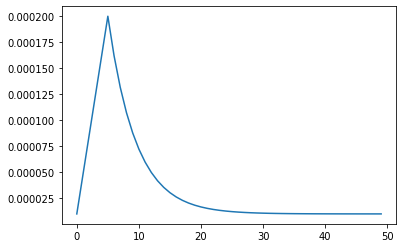

In [7]:
from matplotlib import pyplot as plt

BATCH_SIZE = 64 # 128 works on GPU too but comes very close to the memory limit of the Colab GPU
EPOCHS = 50

print('strategy.num_replicas_in_sync: ', strategy.num_replicas_in_sync)

# batch and learning rate settings
if strategy.num_replicas_in_sync == 8: # TPU or 8xGPU
    BATCH_SIZE = 16 * strategy.num_replicas_in_sync
    VALIDATION_BATCH_SIZE = 16 * strategy.num_replicas_in_sync
    start_lr = 0.00001
    min_lr = 0.00001
    max_lr = 0.00005 * strategy.num_replicas_in_sync
    rampup_epochs = 5
    sustain_epochs = 0
    exp_decay = .8
elif strategy.num_replicas_in_sync == 1: # single GPU
    BATCH_SIZE = 16
    VALIDATION_BATCH_SIZE = 16
    start_lr = 0.00001
    min_lr = 0.00001
    max_lr = 0.0002
    rampup_epochs = 5
    sustain_epochs = 0
    exp_decay = .8
else: # TPU pod
    BATCH_SIZE = 8 * strategy.num_replicas_in_sync
    VALIDATION_BATCH_SIZE = 8 * strategy.num_replicas_in_sync
    start_lr = 0.00001
    min_lr = 0.00001
    max_lr = 0.00002 * strategy.num_replicas_in_sync
    rampup_epochs = 7
    sustain_epochs = 0
    exp_decay = .8

def lrfn(epoch):
    def lr(epoch, start_lr, min_lr, max_lr, rampup_epochs, sustain_epochs, exp_decay):
        if epoch < rampup_epochs:
            lr = (max_lr - start_lr)/rampup_epochs * epoch + start_lr
        elif epoch < rampup_epochs + sustain_epochs:
            lr = max_lr
        else:
            lr = (max_lr - min_lr) * exp_decay**(epoch-rampup_epochs-sustain_epochs) + min_lr
        return lr
    return lr(epoch, start_lr, min_lr, max_lr, rampup_epochs, sustain_epochs, exp_decay)
    
lr_callback = tf.keras.callbacks.LearningRateScheduler(lambda epoch: lrfn(epoch), verbose=True)

rng = [i for i in range(EPOCHS)]
y = [lrfn(x) for x in rng]
plt.plot(rng, [lrfn(x) for x in rng])
print(y[0], y[-1])

learning_rate = y[-1]
print('Learning rate:', learning_rate)

print('Learning rate per epoch:')

In [8]:
! pip install kaggle
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [9]:
! kaggle datasets download yauhenbichel/melanoma

100% 2.62G/2.63G [00:36<00:00, 86.4MB/s]
100% 2.63G/2.63G [00:36<00:00, 77.7MB/s]


In [10]:
import zipfile
! unzip melanoma.zip

Streaming output truncated to the last 5000 lines.
  inflating: melanoma/NotMelanoma/ISIC_0028589.jpg  
  inflating: melanoma/NotMelanoma/ISIC_0028590.jpg  
  inflating: melanoma/NotMelanoma/ISIC_0028591.jpg  
  inflating: melanoma/NotMelanoma/ISIC_0028592.jpg  
  inflating: melanoma/NotMelanoma/ISIC_0028593.jpg  
  inflating: melanoma/NotMelanoma/ISIC_0028594.jpg  
  inflating: melanoma/NotMelanoma/ISIC_0028595.jpg  
  inflating: melanoma/NotMelanoma/ISIC_0028596.jpg  
  inflating: melanoma/NotMelanoma/ISIC_0028597.jpg  
  inflating: melanoma/NotMelanoma/ISIC_0028598.jpg  
  inflating: melanoma/NotMelanoma/ISIC_0028599.jpg  
  inflating: melanoma/NotMelanoma/ISIC_0028600.jpg  
  inflating: melanoma/NotMelanoma/ISIC_0028601.jpg  
  inflating: melanoma/NotMelanoma/ISIC_0028602.jpg  
  inflating: melanoma/NotMelanoma/ISIC_0028603.jpg  
  inflating: melanoma/NotMelanoma/ISIC_0028604.jpg  
  inflating: melanoma/NotMelanoma/ISIC_0028605.jpg  
  inflating: melanoma/NotMelanoma/ISIC_0028606.j

In [11]:
import os

print(len(os.listdir('melanoma/Melanoma')))
print(len(os.listdir('melanoma/NotMelanoma')))

8903
8902


In [12]:
from shutil import copyfile
import random

try:
    os.mkdir('training')
    os.mkdir('validation')
    os.mkdir('testing')
    os.mkdir('training/Melanoma')
    os.mkdir('training/NotMelanoma')
    os.mkdir('validation/Melanoma')
    os.mkdir('validation/NotMelanoma')
    os.mkdir('testing/Melanoma')
    os.mkdir('testing/NotMelanoma')
except OSError:
    pass

def split_data(SOURCE, TRAINING, VALIDATION, TESTING, SPLIT_SIZE):
    files = []
    for filename in os.listdir(SOURCE):
        file = SOURCE + filename
        if os.path.getsize(file) > 0:
            files.append(filename)
        else:
            print(filename + " is zero length, so ignoring.")
 

    dataset_length = len(files)
    validation_length = int(dataset_length * SPLIT_SIZE)
    testing_length = int(dataset_length * SPLIT_SIZE)
    training_length = dataset_length - (testing_length + validation_length)
    
    shuffled_set = random.sample(files, dataset_length)

    training_set = shuffled_set[0:training_length]
    testing_set = shuffled_set[training_length:training_length + testing_length]
    validation_set = shuffled_set[training_length+testing_length:dataset_length]
 
    for filename in training_set:
        this_file = SOURCE + filename
        destination = TRAINING + filename
        copyfile(this_file, destination)
 
    for filename in testing_set:
        this_file = SOURCE + filename
        destination = TESTING + filename
        copyfile(this_file, destination)
    
    for filename in validation_set:
        this_file = SOURCE + filename
        destination = VALIDATION + filename
        copyfile(this_file, destination)
 
 
MELANOMA_SOURCE_DIR = "melanoma/Melanoma/"
NOT_MELANOMA_SOURCE_DIR = "melanoma/NotMelanoma/"

TRAINING_MELANOMA_DIR = "training/Melanoma/"
TRAINING_NOT_MELANOMA_DIR = "training/NotMelanoma/"

VALIDATION_MELANOMA_DIR = "validation/Melanoma/"
VALIDATION_NOT_MELANOMA_DIR = "validation/NotMelanoma/"

TESTING_MELANOMA_DIR = "testing/Melanoma/"
TESTING_NOT_MELANOMA_DIR = "testing/NotMelanoma/"

 
validation_split = 0.19
split_data(MELANOMA_SOURCE_DIR, TRAINING_MELANOMA_DIR, VALIDATION_MELANOMA_DIR, TESTING_MELANOMA_DIR, validation_split)
split_data(NOT_MELANOMA_SOURCE_DIR, TRAINING_NOT_MELANOMA_DIR, VALIDATION_NOT_MELANOMA_DIR, TESTING_NOT_MELANOMA_DIR, validation_split)

In [13]:
print(len(os.listdir('training/Melanoma/')))
print(len(os.listdir('training/NotMelanoma/')))
print(len(os.listdir('validation/Melanoma/')))
print(len(os.listdir('validation/NotMelanoma/')))
print(len(os.listdir('testing/Melanoma/')))
print(len(os.listdir('testing/NotMelanoma/')))

training_data_amount = len(os.listdir('training/Melanoma/')) + len(os.listdir('training/NotMelanoma/'))
validation_data_amount = len(os.listdir('validation/Melanoma/')) + len(os.listdir('validation/NotMelanoma/'))
testing_data_amount = len(os.listdir('testing/Melanoma/')) + len(os.listdir('testing/NotMelanoma/'))

TRAIN_STEPS = training_data_amount // BATCH_SIZE
VALIDATION_STEPS = validation_data_amount // BATCH_SIZE
TEST_STEPS = testing_data_amount // BATCH_SIZE

print("BATCH SIZE: ", BATCH_SIZE)

print("TRAINING IMAGES: ", training_data_amount)
print("VALIDATION IMAGES: ", validation_data_amount)
print("TESTING IMAGES: ", testing_data_amount)

print("TRAIN STEPS: ", TRAIN_STEPS)
print("VALIDATION STEPS: ", VALIDATION_STEPS)
print("TEST STEPS: ", TEST_STEPS)

5521
5520
1691
1691
1691
1691
BATCH SIZE:  16
TRAINING IMAGES:  11041
VALIDATION IMAGES:  3382
TESTING IMAGES:  3382
TRAIN STEPS:  690
VALIDATION STEPS:  211
TEST STEPS:  211


In [14]:
# model = "InceptionV3"
# NUM_CLASSES = 2 : {'Melanoma': 0, 'NotMelanoma': 1}
# The size of images in the dataset is 600x450x3 
# Input Shape: [299, 299, 3]

INPUT_SHAPE = (299, 299)

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255.)
validation_datagen = ImageDataGenerator(rescale=1./255.)
test_datagen = ImageDataGenerator(rescale=1./255.)

TRAINING_DIR = "training/"
train_generator = train_datagen.flow_from_directory(
                      TRAINING_DIR,
                       batch_size=BATCH_SIZE,
                       class_mode='binary',
                       target_size=INPUT_SHAPE)

VALIDATION_DIR = "validation/"
validation_generator = validation_datagen.flow_from_directory(
                       VALIDATION_DIR,
                       batch_size=BATCH_SIZE,
                       class_mode='binary',
                       target_size=INPUT_SHAPE)

TESTING_DIR = "testing/"
test_generator = test_datagen.flow_from_directory(
                      TESTING_DIR,
                       batch_size=BATCH_SIZE,
                       class_mode='binary',
                       target_size=INPUT_SHAPE)


Found 11041 images belonging to 2 classes.
Found 3382 images belonging to 2 classes.
Found 3382 images belonging to 2 classes.


In [16]:
print(train_generator.class_indices)
print(validation_generator.class_indices)
print(test_generator.class_indices)

{'Melanoma': 0, 'NotMelanoma': 1}
{'Melanoma': 0, 'NotMelanoma': 1}
{'Melanoma': 0, 'NotMelanoma': 1}


In [18]:
from tensorflow.keras import layers
from tensorflow.keras import regularizers

def create_inception_v3_base():
  inception_v3_base = tf.keras.applications.inception_v3.InceptionV3(
      weights='imagenet', # Load weights pre-trained on ImageNet.
      include_top=False, # Do not include the ImageNet classifier at the top.
      input_shape=[*INPUT_SHAPE, 3])
  
  #freeze base model
  inception_v3_base.trainable = False

  return inception_v3_base

def create_inception_v3_model():
  modelInceptionV3 = tf.keras.Sequential([
      create_inception_v3_base(),
      layers.GlobalAveragePooling2D(),
      layers.Dropout(0.2),
      layers.Dense(64, activation ='relu',kernel_regularizer = regularizers.l2(0.001)),
      layers.Dropout(0.2),
      layers.Dense(1, activation ='sigmoid')
    ])
    
  modelInceptionV3.compile(
      optimizer = tf.keras.optimizers.Adam(),
      loss = tf.keras.losses.BinaryCrossentropy(from_logits=True),
      metrics = [tf.keras.metrics.BinaryAccuracy()]
    )
  
  return modelInceptionV3


with strategy.scope(): # creating the model in the TPUStrategy scope places the model on the TPU
  modelInceptionV3 = create_inception_v3_model()
  
modelInceptionV3.summary()

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


...

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


87924736/87910968 [==============================] - 0s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v3 (Functional)   (None, 8, 8, 2048)        21802784  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 64)                131136    
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 65

In [19]:
import time
import numpy as np

start_time = time.time()

history = modelInceptionV3.fit(train_generator,
                            epochs = EPOCHS,
                            verbose = 1,
                            callbacks = [lr_callback],
                            validation_data = validation_generator,
                            steps_per_epoch = TRAIN_STEPS)

end_date = time.time()

final_accuracy = history.history["val_binary_accuracy"][-5:]
print("FINAL ACCURACY MEAN-5: ", np.mean(final_accuracy))
print("TRAINING TIME: ", end_date - start_time, " sec")


Epoch 1: LearningRateScheduler setting learning rate to 1e-05.
Epoch 1/50


/usr/local/lib/python3.7/dist-packages/tensorflow/python/util/dispatch.py:1082: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a sigmoid or softmax activation and thus does not represent logits. Was this intended?"
  return dispatch_target(*args, **kwargs)


690/690 [==============================] - 108s 133ms/step - loss: 0.6917 - binary_accuracy: 0.7184 - val_loss: 0.5597 - val_binary_accuracy: 0.8486 - lr: 1.0000e-05

Epoch 2: LearningRateScheduler setting learning rate to 4.8e-05.
Epoch 2/50
690/690 [==============================] - 87s 126ms/step - loss: 0.4432 - binary_accuracy: 0.8810 - val_loss: 0.3543 - val_binary_accuracy: 0.9190 - lr: 4.8000e-05

Epoch 3: LearningRateScheduler setting learning rate to 8.6e-05.
Epoch 3/50
690/690 [==============================] - 87s 126ms/step - loss: 0.3521 - binary_accuracy: 0.9146 - val_loss: 0.3149 - val_binary_accuracy: 0.9311 - lr: 8.6000e-05

Epoch 4: LearningRateScheduler setting learning rate to 0.000124.
Epoch 4/50
690/690 [==============================] - 87s 126ms/step - loss: 0.3229 - binary_accuracy: 0.9189 - val_loss: 0.2842 - val_binary_accuracy: 0.9279 - lr: 1.2400e-04

Epoch 5: LearningRateScheduler setting learning rate to 0.000162.
Epoch 5/50
690/690 [====================

In [24]:
# We can save our model with:
modelInceptionV3.save('modelInceptionV3ApproachA.h5')
# and reload it with:
reloaded_model = tf.keras.models.load_model('modelInceptionV3ApproachA.h5')

In [21]:
test_loss, test_acc = modelInceptionV3.evaluate_generator(
    test_generator, 
    steps = TEST_STEPS, 
    verbose = 1)

print('TEST ACCURACY:', test_acc)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  after removing the cwd from sys.path.


211/211 [==============================] - 21s 98ms/step - loss: 0.1848 - binary_accuracy: 0.9416
TEST ACCURACY: 0.941646933555603


<Figure size 432x288 with 0 Axes>

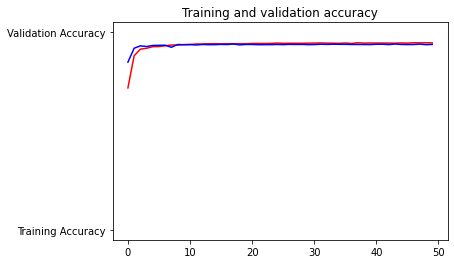

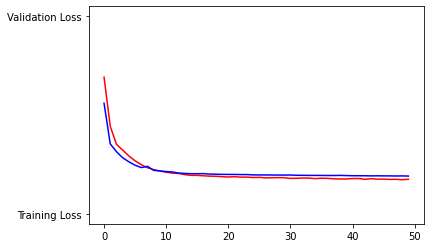

<Figure size 432x288 with 0 Axes>

In [22]:
%matplotlib inline
import matplotlib.image  as mpimg
import matplotlib.pyplot as plt

acc=history.history['binary_accuracy']
val_acc=history.history['val_binary_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']
 
epochs=range(len(acc)) # Get number of epochs
 
plt.plot(epochs, acc, 'r', "Training Accuracy")
plt.plot(epochs, val_acc, 'b', "Validation Accuracy")
plt.title('Training and validation accuracy')
plt.figure()

plt.plot(epochs, loss, 'r', "Training Loss")
plt.plot(epochs, val_loss, 'b', "Validation Loss")
plt.figure()

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy', 'lr'])


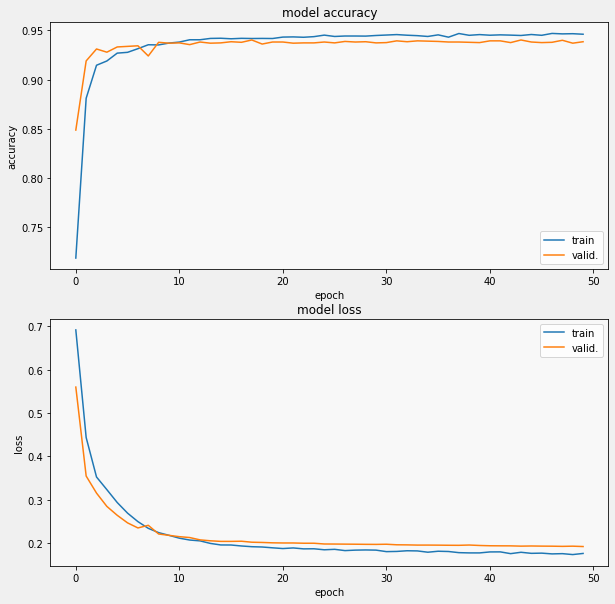

In [23]:
print(history.history.keys())

def display_training_curves(training, validation, title, subplot):
  if subplot%10==1: # set up the subplots on the first call
    plt.subplots(figsize=(10,10), facecolor='#F0F0F0')
    #plt.tight_layout()
  ax = plt.subplot(subplot)
  ax.set_facecolor('#F8F8F8')
  ax.plot(training)
  ax.plot(validation)
  ax.set_title('model '+ title)
  ax.set_ylabel(title)
  ax.set_xlabel('epoch')
  ax.legend(['train', 'valid.'])

display_training_curves(history.history['binary_accuracy'], history.history['val_binary_accuracy'], 'accuracy', 211)
display_training_curves(history.history['loss'], history.history['val_loss'], 'loss', 212)